# Análisis de logs distribuidos

Objetivo: Detectar el momento crítico del sistema y explicar qué servicio, endpoint y mensajes fueron los más afectados

# Imports
### "Pandas" --> Utilizado para trabajar con el file .csv 
-Cargar el archivo.  
-Convertir columnas.  
-Agrupar por ventanas de tiempo.  
-Conteo de eventos.  
-Cálculo de operaciones (%)  
-Creación de tablas de resumen
### "Matplotlib" --> Utilizado para la creación de los gráficos
-Se aplica para visualizar tendencias temporales.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Carga y validacion de datos
Se carga el file .CSV como un DataFrame y se validan los datos antes de empezar a trabajar con ellos.  
Un DataFrame es una tabla en memoria, donde cada fila representa un log y cada columna es una categoría de datos relevantes para el análisis, tales como:   
-El horario en el que se produjo el evento.  
-El nombre del servicio afectado.  
-La severidad del incidente.  
-El endpoint afectado.  
-El status code.  
-La latencia.  
-etc

In [4]:
# Bloque de carga y validación de datos

df = pd.read_csv("server_logs.csv") # --> Carga del file "server_logs.csv" en un DataFrame

# Estas son las 10 columnas obligatorias que solicita el challenge
required_columns = [
    "timestamp_event",
    "received_at",
    "service_name",
    "severity",
    "message",
    "method",
    "endpoint",
    "status_code",
    "latency_ms",
    "trace_id",
]

# Variable de control de cantidad (columnas mínimas)
missing_columns = sorted(set(required_columns) - set(df.columns)) # Se aplica sets para poder hacer operaciones.
if missing_columns:
    raise ValueError(f"Faltan columnas obligatorias: {missing_columns}") # --> Se detiene con un error porque no están las columnas mínimas.

# Conversión de datatypes
df["timestamp_event"] = pd.to_datetime(df["timestamp_event"], utc=True) #datetime
df["received_at"] = pd.to_datetime(df["received_at"], utc=True) #datetime
df["status_code"] = pd.to_numeric(df["status_code"], errors="coerce") #numeric
df["latency_ms"] = pd.to_numeric(df["latency_ms"], errors="coerce") #numeric
df = df.sort_values("timestamp_event").reset_index(drop=True) # Se ordena de la fecha + antigua a la reciente. Se resetean los índices y se genera uno nuevo según el sorting.
# errors = coerce --> Suponiendo que se completa con algo no esperado como un "ERROR", "texto:corrupto" o "espacio en blanco" pasa a un valor vacío NaN (Not a Number)

# Prints para indicar la cantidad de logs del dataset cargado y el rango temporal a analizar
print(f"Dataset cargado: {len(df):,} logs")
print(f"Rango temporal: {df['timestamp_event'].min()} -> {df['timestamp_event'].max()}")

Dataset cargado: 5,795 logs
Rango temporal: 2026-01-10 00:02:39.029160+00:00 -> 2026-01-12 23:59:23.187914+00:00


# Definiciones operativas obligatorias y definición de un "bad_event"

In [5]:
# Bloque de definición de flujo operativo

# Agrupación por bloques definidos temporalmente cada 5 minutos (Si algo ocurre a las 19:24:48 se le asigna la ventana bin de 19:20:00)
df["window_start"] = df["timestamp_event"].dt.floor("5min") # --> Cada log se asigna a una ventana de 5 minutos usando `timestamp_event`.
# Identificación de errores 5XX
df["is_5xx"] = df["status_code"] >= 500 # --> Log marcado como >= 500, lo que supone un error del lado del server.
# Definición y condiciones del bad event
df["is_bad_event"] = df["severity"].isin(["ERROR", "CRITICAL"]) | df["is_5xx"] # --> Se considera "bad_event" si su severidad es ERROR o CRITICAL o su status code >= 500.

# Se crea un df de "bad_event"
bad_df = df[df["is_bad_event"]].copy() # --> Esto va a usarse para el cálculo de mensajes de error y diagnóstico del incidente.

# Impresión de bad_events y % sobre el total de logs
print(f"Bad events totales: {df['is_bad_event'].sum():,}")
print(f"Bad rate global: {df['is_bad_event'].mean():.2%}")
print("-" * 50)

# Agrupamos por ventana para calcular el total de eventos y los eventos malos
# (En Python, sumar un booleano True/False cuenta los True automáticamente)
window_summary = df.groupby("window_start").agg(
    total_events=("is_bad_event", "count"),
    bad_events=("is_bad_event", "sum")
).reset_index()

# BAD RATE (Por ventana)
# Calculamos la tasa directamente dividiendo las columnas de Pandas
window_summary["bad_rate"] = window_summary["bad_events"] / window_summary["total_events"]

# MOMENTO CRÍTICO
# Aplicamos el filtro obligatorio: ventanas con 20 o más eventos totales
filtered_windows = window_summary[window_summary["total_events"] >= 20]

if not filtered_windows.empty:
    # Encontramos la fila con el bad_rate más alto usando idxmax de Pandas
    critical_row_idx = filtered_windows["bad_rate"].idxmax()
    critical_row = filtered_windows.loc[critical_row_idx]
    
    momento_critico_window = critical_row["window_start"]
    
    print(f"Momento Crítico Detectado:")
    print(f"Ventana: {momento_critico_window}")
    print(f"Eventos totales en la ventana: {critical_row['total_events']}")
    print(f"Bad Rate de la ventana: {critical_row['bad_rate']:.2%}")
else:
    momento_critico_window = None
    print("No se encontraron ventanas con >= 20 eventos. No se puede definir un Momento Crítico.")

print("-" * 50)

# Baseline
# Dividimos el dataset original usando filtros booleanos de Pandas
if momento_critico_window is not None:
    df_momento_critico = df[df["window_start"] == momento_critico_window].copy()
    df_baseline = df[df["window_start"] != momento_critico_window].copy()
    
    print(f"Flujo Operativo Segmentado con Éxito:")
    print(f"Registros en Momento Crítico: {len(df_momento_critico):,}")
    print(f"Registros en Baseline (Resto del dataset): {len(df_baseline):,}")
else:
    df_baseline = df.copy()
    print("ℹAl no haber momento crítico, el Baseline incluye el 100% de los datos.")


Bad events totales: 895
Bad rate global: 15.44%
--------------------------------------------------
Momento Crítico Detectado:
Ventana: 2026-01-10 11:10:00+00:00
Eventos totales en la ventana: 189
Bad Rate de la ventana: 58.20%
--------------------------------------------------
Flujo Operativo Segmentado con Éxito:
Registros en Momento Crítico: 189
Registros en Baseline (Resto del dataset): 5,606


# 1- Exploración inicial
Responde con tablas a las preguntas:  
1) ¿Cuántos logs hay en total?
2) ¿Qué severidad aparece más?
3) ¿Qué servicio genera más logs? (Y el que genera menos)
4) ¿Cuál es el mensaje más repetido?
5) ¿Cuál es el mensaje "malo" más repetido (bad events)?

In [6]:
# Bloque de exploración inicial
message_counts = df["message"].value_counts()
bad_message_counts = bad_df["message"].value_counts()
service_counts = df["service_name"].value_counts()

# Creación del Df - Exploracion inicial
exploracion_inicial = pd.DataFrame(
    [
        {"pregunta": "Logs totales", "respuesta": len(df)}, # --> Conteo de todos los valores
        {"pregunta": "Severidad mas frecuente", "respuesta": df["severity"].value_counts().idxmax()}, # Conteo total + idmax, saca el mayor
        {"pregunta": "Servicio con mas logs", "respuesta": service_counts.idxmax()},
        {"pregunta": "Servicio con menos logs", "respuesta": service_counts.idxmin()}, # Conteo total + idmin, saca el menor
        {"pregunta": "Mensaje mas repetido", "respuesta": message_counts.idxmax()},
        {
            "pregunta": "Mensaje malo mas repetido",
            "respuesta": bad_message_counts.idxmax() if not bad_message_counts.empty else "Sin bad events", # Garantía por si todas las filas quedan SIN errores.
        },
    ]
)

exploracion_inicial

,pregunta,respuesta
0,Logs totales,5795
1,Severidad mas frecuente,INFO
2,Servicio con mas logs,api-gateway
3,Servicio con menos logs,notification-service
4,Mensaje mas repetido,Health check OK
5,Mensaje malo mas repetido,Order creation failed - inventory lock timeout


# 2- Deteccion del momento critico

In [7]:
# Bloque de detección del momento crítico

window_summary = (
    df.groupby("window_start") # Agrupa todos los logs que pertenecen a la misma ventana de inicio de 5 minutos
    .agg( # --> Cálcuo en función a:
        total_events=("trace_id", "size"), # --> N logs totales
        bad_events=("is_bad_event", "sum"), # --> Eventos malos
        avg_latency_ms=("latency_ms", "mean"), # --> promedio de latencia
        events_5xx=("is_5xx", "sum"), # --> Suma de respones HTTP 5XX
    )
    .reset_index() # --> reset del windows_start
)
# Cálculo del bad_rate y el % 5XX
window_summary["bad_rate"] = window_summary["bad_events"] / window_summary["total_events"]
window_summary["pct_5xx"] = window_summary["events_5xx"] / window_summary["total_events"]

# Filtro de volumen mínimo >= 20 logs
eligible_windows = window_summary[window_summary["total_events"] >= 20].copy()
if eligible_windows.empty: 
    raise ValueError("No hay ventanas de 5 minutos con total_events >= 20") # Error si no se cumple la condición

# Top de 5 peores ventanas temporales de 5 minutos
top_5_windows = (
    eligible_windows.sort_values(
        ["bad_rate", "bad_events", "total_events"],
        ascending=[False, False, False], # False para orden descendente en las 3 categorías
        # 1) Bad_rate, Primero analiza y pone los que tienen mayor % de bad_rate (bad_events/total_events)
        # 2) Bad_events, Mayor cantidad de bad events
        # 3) Total_events, cantidad total de eventos
        # Irá ordenando en ese orden y esa jerarquía
    )
    .head(5) # Solo los Top5
    [["window_start", "total_events", "bad_events", "bad_rate"]]
    .reset_index(drop=True)
)

critical_window_start = top_5_windows.loc[0, "window_start"] # --> Inicio de la ventana
critical_window_end = critical_window_start + pd.Timedelta(minutes=5) # --> Calculo al final sumando 5 minutos

# Impresión para indicar la ventana temporal con mayor bad_rates --> Momento crítico
print(f"Momento critico seleccionado: {critical_window_start} -> {critical_window_end}")
top_5_windows

Momento critico seleccionado: 2026-01-10 11:10:00+00:00 -> 2026-01-10 11:15:00+00:00


,window_start,total_events,bad_events,bad_rate
0,2026-01-10 11:10:00+00:00,189,110,0.582011
1,2026-01-10 11:15:00+00:00,228,129,0.565789
2,2026-01-10 11:20:00+00:00,111,59,0.531532
3,2026-01-11 14:35:00+00:00,255,117,0.458824
4,2026-01-11 14:30:00+00:00,156,68,0.435897


# 3- Diagnostico dentro del momento critico

Criterio elegido: por cantidad de bad events.

In [8]:
# bloque de diagnóstico del momento crítico viendo relación entre eventos totales y eventos malos
in_critical_window = (df["timestamp_event"] >= critical_window_start) & (df["timestamp_event"] < critical_window_end)
incident_df = df[in_critical_window].copy()
baseline_df = df[~in_critical_window].copy()
bad_incident_df = incident_df[incident_df["is_bad_event"]].copy()

print(f"Eventos en momento critico: {len(incident_df):,}")
print(f"Bad events en momento critico: {len(bad_incident_df):,}")

Eventos en momento critico: 189
Bad events en momento critico: 110


## Bad events por servicio

In [9]:
# Bloque de diagnóstico por servicios del bad_events
bad_events_by_service = (
    bad_incident_df.groupby("service_name")
    .size()
    .rename("bad_events")
    .sort_values(ascending=False)
    .reset_index()
)

bad_events_by_service

,service_name,bad_events
0,orders-service,72
1,inventory-service,37
2,payment-service,1


## Top 5 mensajes en bad events

In [10]:
# Bloque con los top 5 mensajes de los bad_events
top_5_bad_messages = (
    bad_incident_df["message"]
    .value_counts()
    .head(5)
    .rename_axis("message")
    .reset_index(name="bad_events")
)

top_5_bad_messages

,message,bad_events
0,Order creation failed - inventory lock timeout,72
1,Database deadlock detected,37
2,External dependency error,1


## Top 5 endpoints mas comprometidos

In [11]:
# Top 5 endpoints comprometidos según el diagnóstico del evento crítico
top_5_compromised_endpoints = (
    bad_incident_df.groupby("endpoint")
    .agg(
        bad_events=("endpoint", "size"),
        events_5xx=("is_5xx", "sum"),
        avg_latency_ms=("latency_ms", "mean"),
    )
    .sort_values(["bad_events", "events_5xx", "avg_latency_ms"], ascending=[False, False, False])
    .head(5)
    .round({"avg_latency_ms": 2})
    .reset_index()
)

top_5_compromised_endpoints

,endpoint,bad_events,events_5xx,avg_latency_ms
0,/orders/cancel,26,26,2066.62
1,/orders/create,25,25,2339.28
2,/orders/status,21,21,2343.29
3,/inv/reserve,18,18,2374.89
4,/inv/stock,13,13,2321.38


# 4- Cambios: Incidente (momento crítico) vs Baseline

In [ ]:
# Bloque comparativo entre el momento crítico y el baseline
def resumen_periodo(data):
    return pd.Series(
        {
            "total_events": len(data), # --> N eventos
            "bad_rate": data["is_bad_event"].mean(), # --> promedio de bad_rate
            "avg_latency_ms": data["latency_ms"].mean(), # --> promedio latencia
            "%_5xx": data["is_5xx"].mean(), # --> promedio % 5XX
        }
    )

# Tabla comparativa 
incident_vs_baseline = pd.DataFrame(
    {
        "momento_critico": resumen_periodo(incident_df),
        "baseline": resumen_periodo(baseline_df),
    }
).T # Transpone para que los períodos pasen a ser filas y las métricas columnas

incident_vs_baseline["total_events"] = incident_vs_baseline["total_events"].astype(int) # --> Lo pasamos como int porque transponer lo pasa a floar
incident_vs_baseline[["bad_rate", "avg_latency_ms", "%_5xx"]] = incident_vs_baseline[
    ["bad_rate", "avg_latency_ms", "%_5xx"]
].round(4)

incident_vs_baseline

,total_events,bad_rate,avg_latency_ms,%_5xx
momento_critico,189,0.582,1589.6878,0.582
baseline,5606,0.140,521.0944,0.140


## Grafico 1: eventos por severidad en bins de 5 minutos

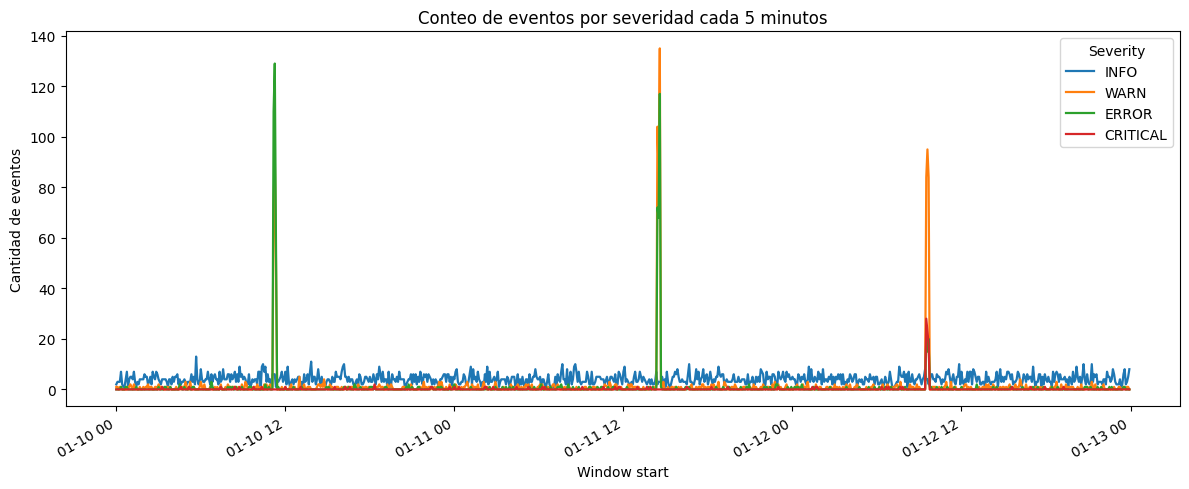

In [ ]:
severity_order = ["INFO", "WARN", "ERROR", "CRITICAL"]
severity_time = (
    df.groupby(["window_start", "severity"]) # --> Por ventana de tiempo y severidad
    .size()
    .unstack(fill_value=0) # --> Severidad en columnas, aplicando NaN si viene al caso
    .reindex(columns=severity_order, fill_value=0) # --> Columnas según severity order
)

ax = severity_time.plot(figsize=(12, 5), linewidth=1.6)
ax.set_title("Conteo de eventos por severidad cada 5 minutos") # --> Título
ax.set_xlabel("Window start") # --> Etiqueta X 
ax.set_ylabel("Cantidad de eventos") # --> Etiqueta Y
ax.legend(title="Severity") # Leyenda con las severidades
plt.tight_layout() # --> Ajuste para que no se corten las etiquetas
plt.show()

## Grafico 2: bad rate en bins de 5 minutos

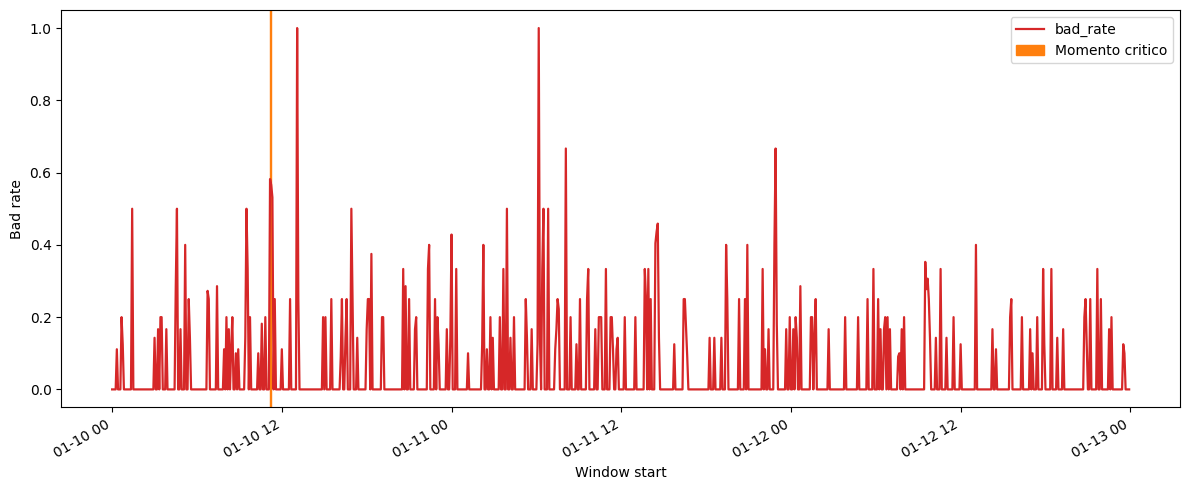

In [ ]:
bad_rate_time = window_summary.set_index("window_start")["bad_rate"]

ax = bad_rate_time.plot(figsize=(12, 5), linewidth=1.6, color="tab:red") # --> Bad_rate a lo largo del tiempo en rojo
ax.axvspan(critical_window_start, critical_window_end, color="tab:orange", alpha=1, label="Momento critico") # --> Señala el momento crítico
ax.set_xlabel("Window start") # --> EEtiqueta X
ax.set_ylabel("Bad rate") # --> Etiqueta Y
ax.legend() # --> Leyenda autofilleada por las etiquetas
plt.tight_layout() # --> Ajuste de etiquetas
plt.show()

# Conclusiones

In [15]:
servicio_mas_afectado = bad_events_by_service.loc[0, "service_name"] if not bad_events_by_service.empty else "Sin bad events"
endpoint_mas_comprometido = top_5_compromised_endpoints.loc[0, "endpoint"] if not top_5_compromised_endpoints.empty else "Sin bad events"
mensaje_dominante = top_5_bad_messages.loc[0, "message"] if not top_5_bad_messages.empty else "Sin bad events"

incident_metrics = incident_vs_baseline.loc["momento_critico"]
baseline_metrics = incident_vs_baseline.loc["baseline"]

print(f"1. Momento critico: {critical_window_start} a {critical_window_end}.")
print(f"2. En esa ventana hubo {int(incident_metrics['total_events'])} eventos y un bad_rate de {incident_metrics['bad_rate']:.2%}.")
print(f"3. El servicio mas afectado fue {servicio_mas_afectado}, usando el criterio de cantidad de bad events.")
print(f"4. El endpoint mas comprometido fue {endpoint_mas_comprometido}.")
print(f"5. El mensaje dominante entre los bad events fue: {mensaje_dominante}.")
print(f"6. Contra el baseline, el bad_rate paso de {baseline_metrics['bad_rate']:.2%} a {incident_metrics['bad_rate']:.2%}.")
print(f"7. La latencia promedio paso de {baseline_metrics['avg_latency_ms']:.2f} ms en baseline a {incident_metrics['avg_latency_ms']:.2f} ms en el incidente.")
print(f"8. El porcentaje de 5xx paso de {baseline_metrics['%_5xx']:.2%} a {incident_metrics['%_5xx']:.2%}.")

1. Momento critico: 2026-01-10 11:10:00+00:00 a 2026-01-10 11:15:00+00:00.
2. En esa ventana hubo 189 eventos y un bad_rate de 58.20%.
3. El servicio mas afectado fue orders-service, usando el criterio de cantidad de bad events.
4. El endpoint mas comprometido fue /orders/cancel.
5. El mensaje dominante entre los bad events fue: Order creation failed - inventory lock timeout.
6. Contra el baseline, el bad_rate paso de 14.00% a 58.20%.
7. La latencia promedio paso de 521.09 ms en baseline a 1589.69 ms en el incidente.
8. El porcentaje de 5xx paso de 14.00% a 58.20%.
